Original shape: (891, 8)
After PCA shape: (891, 2)


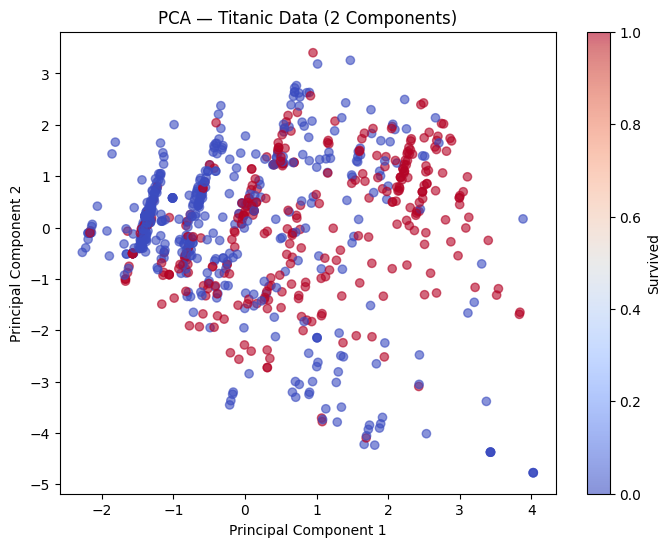

Variance explained: [0.25978643 0.21198773]
Total variance kept: 47.177415357208176 %


In [4]:
#PCA (PRINCIPAL COMPONENT ANALYSIS)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r'D:\Python\ML\Data_Preprocessing\train.csv')
df['Age'] = df['Age'].fillna(df['Age'].median())
df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
df['Fare'] = df['Fare'].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)


X = df.drop(columns=['Survived'])
y = df['Survived']

scaler = StandardScaler()
# fit: learns mean and SD of each column
#transform projects 8 features into 2 directions
X_scaled = scaler.fit_transform(X)

#Only two components or features that are actually necessary
pca = PCA(n_components=2)
#Here in pca fit is used to find the most important DIRECTIONS in data (using Eigenvectors)
#Brings the data into same scale
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("After PCA shape:", X_pca.shape)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6)#c=y i.e coloring based on y column and alpha means transparency 1 is solid 0 is transparent
plt.title('PCA — Titanic Data (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Survived')
plt.show()

# So how much variance is explained suppose the variance is (0.3,0.1) then 30% from component 1 and 10 percent from component 2 is derived
print("Variance explained:", pca.explained_variance_ratio_)
print("Total variance kept:", sum(pca.explained_variance_ratio_)*100, "%")# From above comment 40% data is extracted from the original data